<img src='http://hilpisch.com/taim_logo.png' width="350px" align="right">

# AI in Finance

**Market Prediction**

&copy; Dr Yves J Hilpisch | The Python Quants GmbH

http://tpq.io | http://twitter.com/dyjh

## Imports

In [1]:
import math
import numpy as np
import pandas as pd
from pylab import plt
plt.style.use('seaborn')
%matplotlib inline

## The Data

In [2]:
url = 'http://hilpisch.com/oanda_eur_usd.csv'

In [3]:
raw = pd.read_csv(url, index_col=0,
                  parse_dates=True).dropna()

In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15456 entries, 2018-01-01 22:00:00 to 2019-03-29 20:30:00
Data columns (total 6 columns):
c           15456 non-null float64
complete    15456 non-null bool
h           15456 non-null float64
l           15456 non-null float64
o           15456 non-null float64
volume      15456 non-null int64
dtypes: bool(1), float64(4), int64(1)
memory usage: 739.6 KB


## The Features

The following creates a **set of financial features**.

In [5]:
data = raw.copy()

# log returns & direction
data['r'] = np.log(data['c'] / data['c'].shift(1))
data['rs'] = (data['r'] - data['r'].mean()) / data['r'].std()
data['d'] = np.where(data['r'] > 0, 1, 0)

In [6]:
# rolling statistics
data['v1'] = data['r'].rolling(20).std()
data['v2'] = data['r'].rolling(100).std()
data['sma1'] = data['c'].rolling(20).mean()
data['sma2'] = data['c'].rolling(100).mean()
data['mom1'] = data['r'].rolling(5).mean()
data['mom2'] = data['r'].rolling(20).mean()

In [7]:
data.dropna(inplace=True)

In [8]:
features = list(data.columns)
features.remove('complete')

In [9]:
ld = len(data)
ld

15356

## Data Preprocessing

The data set is split into **train, validation and test data sets**.

In [10]:
split = int(len(data) * 0.7)
val_size = int(split * 0.15)

In [11]:
train = data.iloc[:split]
val = train[-val_size:]
train = train[:-val_size]
test = data.iloc[split:].copy()

In [12]:
lags = 10

In [13]:
def gaussian(x):
    mean = x.mean()
    std = x.std()
    return (x - mean) / std, mean, std

The following function creates **lags** of the features columns and **normalizes** the data.

In [14]:
def normalize_and_lag():
    global cols
    cols = []
    for f in features:
        for lag in range(1, lags + 1):
            col = f'{f}_lag_{lag}'
            if f in ['r', 'rs', 'd', 'u-d']:
                train[col] = train[f].shift(lag)
                val[col] = val[f].shift(lag)
                test[col] = test[f].shift(lag)
            else:
                train[col], mean, std = gaussian(train[f].shift(lag))
                val[col] = (val[f].shift(lag) - mean) / std
                test[col] = (test[f].shift(lag) - mean) / std
            cols.append(col)
    train.dropna(inplace=True)
    val.dropna(inplace=True)
    test.dropna(inplace=True)

In [15]:
normalize_and_lag()

In [16]:
len(cols)

140

In [17]:
# train.head(5)

## Backtesting

### Scikit-Learn

First, a `MLPClassifier` is trained.

In [18]:
from sklearn.neural_network import MLPClassifier

In [19]:
np.random.seed(100)

In [20]:
model = MLPClassifier(hidden_layer_sizes=(256, 256),
                      activation='relu',
                      alpha=0.0001,
                      random_state=100,
                      max_iter=200,
                      validation_fraction=0.0,
                      shuffle=False,
                      early_stopping=False,
                      verbose=False)

In [21]:
%time model.fit(train[cols], train['d'])

CPU times: user 1min 41s, sys: 9.83 s, total: 1min 51s
Wall time: 18.6 s


MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
       beta_2=0.999, early_stopping=False, epsilon=1e-08,
       hidden_layer_sizes=(256, 256), learning_rate='constant',
       learning_rate_init=0.001, max_iter=200, momentum=0.9,
       n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,
       random_state=100, shuffle=False, solver='adam', tol=0.0001,
       validation_fraction=0.0, verbose=False, warm_start=False)

Second, the trained model is used to predict the **future market direction**.

In [22]:
test['p'] = model.predict(test[cols])
test['p'] = np.where(test['p'] > 0, 1, -1)

In [23]:
test['s'] = test['p'] * test['r']

A look at the **positions** and the **number of trades**.

In [24]:
test['p'].value_counts()

 1    3008
-1    1589
Name: p, dtype: int64

In [25]:
sum(test['p'].diff() != 0)

1764

The model **outperforms** the passive benchmark investment by a few percentage points.

<b style="color:red;">CAUTION: The analysis is implemented under the assumption of zero transaction costs.<b>

In [26]:
test[['r', 's']].sum().apply(np.exp)

r    0.992410
s    1.046602
dtype: float64

In [27]:
test[['r', 's']].std()

r    0.000602
s    0.000602
dtype: float64

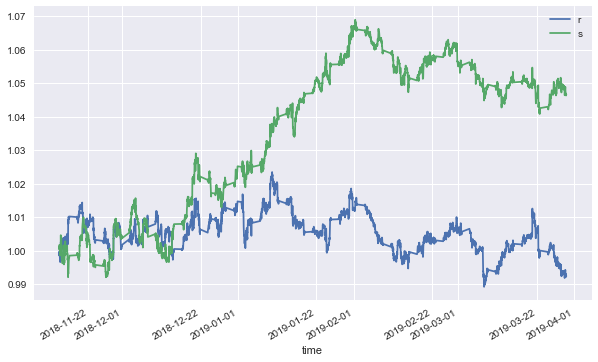

In [28]:
test[['r', 's']].cumsum().apply(np.exp).plot(figsize=(10, 6));

### Keras

A dense neural network with `Keras` is built and trained.

In [29]:
import tensorflow as tf
tf.logging.set_verbosity(tf.logging.ERROR)
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

Using TensorFlow backend.


In [30]:
np.random.seed(100)
tf.random.set_random_seed(100)

In [31]:
model = Sequential()

model.add(Dense(128, activation='relu',
                kernel_regularizer=l2(0.001),
                input_shape=(len(cols),)
               )
         )
model.add(Dropout(0.3, seed=100))
model.add(Dense(128, activation='relu',
                kernel_regularizer=l2(0.001)
               )
         )
model.add(Dropout(0.3, seed=100))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [32]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 128)               18048     
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               16512     
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 129       
Total params: 34,689
Trainable params: 34,689
Non-trainable params: 0
_________________________________________________________________


In [33]:
callbacks = [EarlyStopping(monitor='val_acc', patience=25)]

In [34]:
%%time
model.fit(train[cols], train['d'],
          epochs=250, batch_size=32, verbose=False,
          validation_data=(val[cols], val['d']),
          callbacks=callbacks);

CPU times: user 21.5 s, sys: 6.77 s, total: 28.2 s
Wall time: 10.6 s


A look at how the **metrics** evolve over the training periods.

In [35]:
res = pd.DataFrame(model.history.history)

In [36]:
res.tail(3)

,val_loss,val_acc,loss,acc
29,0.693369,0.530587,0.692790,0.522187
30,0.695514,0.503121,0.693074,0.521749
31,0.697411,0.503745,0.692624,0.526679


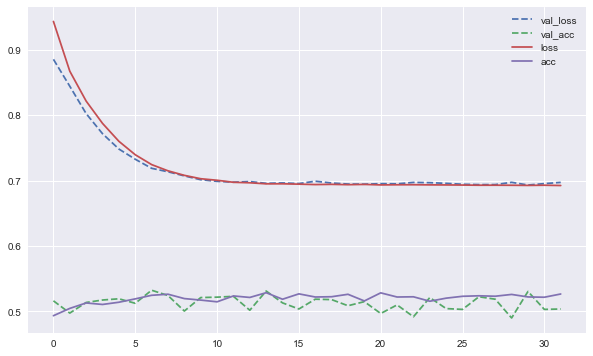

In [37]:
res.plot(figsize=(10, 6), style=['--', '--', '-', '-']);

The trained model is used to generate **directional market predictions** on the test data set.

In [38]:
model.evaluate(test[cols], test['d'])

4597/4597 [==============================] - 0s 13us/step


[0.6929880122218361, 0.522732216779735]

In [39]:
test['p'] = model.predict_classes(test[cols])
test['p'] = np.where(test['p'] > 0, 1, -1)

In [40]:
test['s'] = test['p'] * test['r']

A look at the **positions** and the **number of trades**.

In [41]:
test['p'].value_counts()

 1    3042
-1    1555
Name: p, dtype: int64

In [42]:
sum(test['p'].diff() != 0)

1123

The model **outperforms** the passive benchmark investment.

<b style="color:red;">CAUTION: The analysis is implemented under the assumption of zero transaction costs.<b>

In [43]:
test[['r', 's']].sum().apply(np.exp)

r    0.992410
s    1.078215
dtype: float64

In [44]:
test[['r', 's']].std()

r    0.000602
s    0.000602
dtype: float64

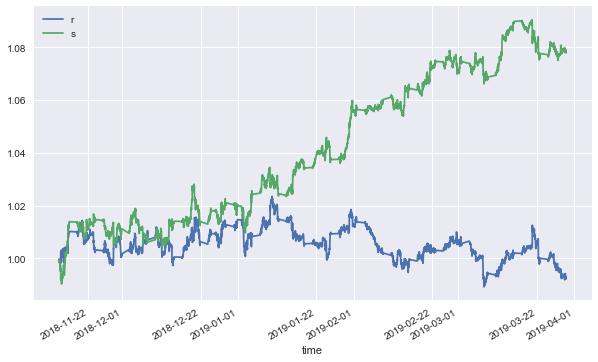

In [45]:
test[['r', 's']].cumsum().apply(np.exp).plot(figsize=(10, 6));

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>